Generating training data...
Training model...
Epoch 1/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0084
Epoch 2/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.1636e-04
Epoch 3/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.0443e-05
Epoch 4/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2282e-05
Epoch 5/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2446e-05
Epoch 6/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.4608e-05
Epoch 7/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.9602e-05
Epoch 8/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4745e-05
Epoch 9/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.6074e-05
Epoch 10/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.9502e-05
Epoch 11/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.9579e-05
Epoch 12/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6597e-05
Epoch 13/200
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.0207e-05
Epoch 14/200
782/7

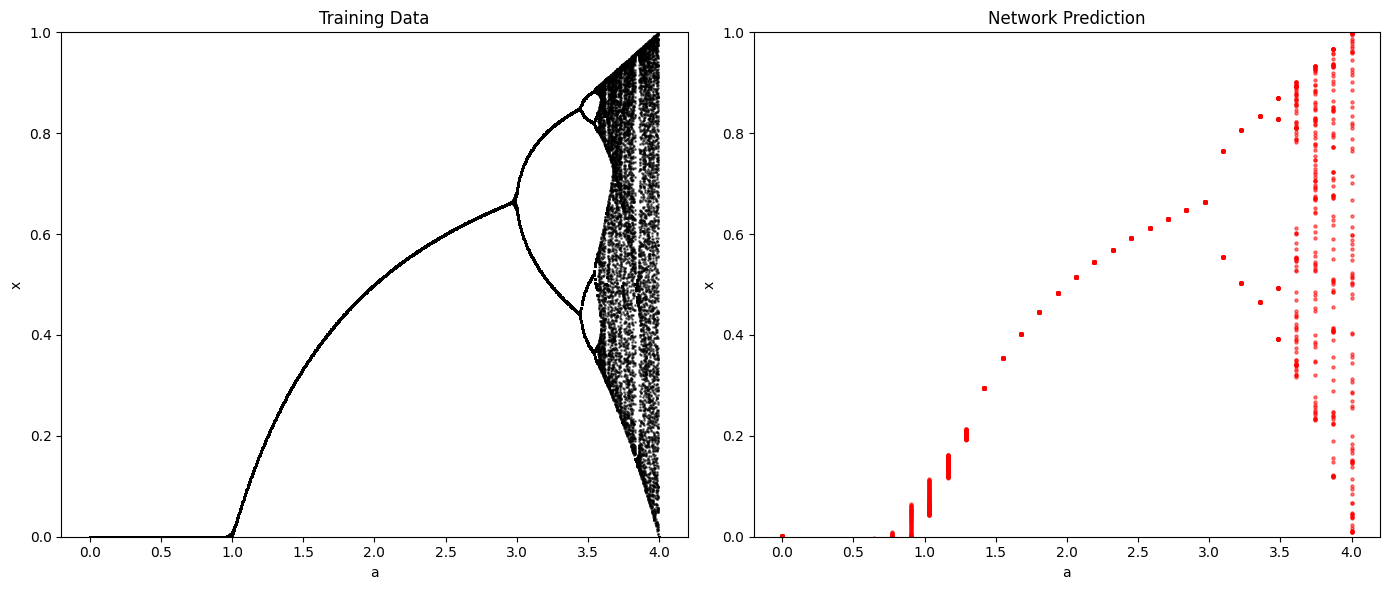

Visualizing single path prediction...


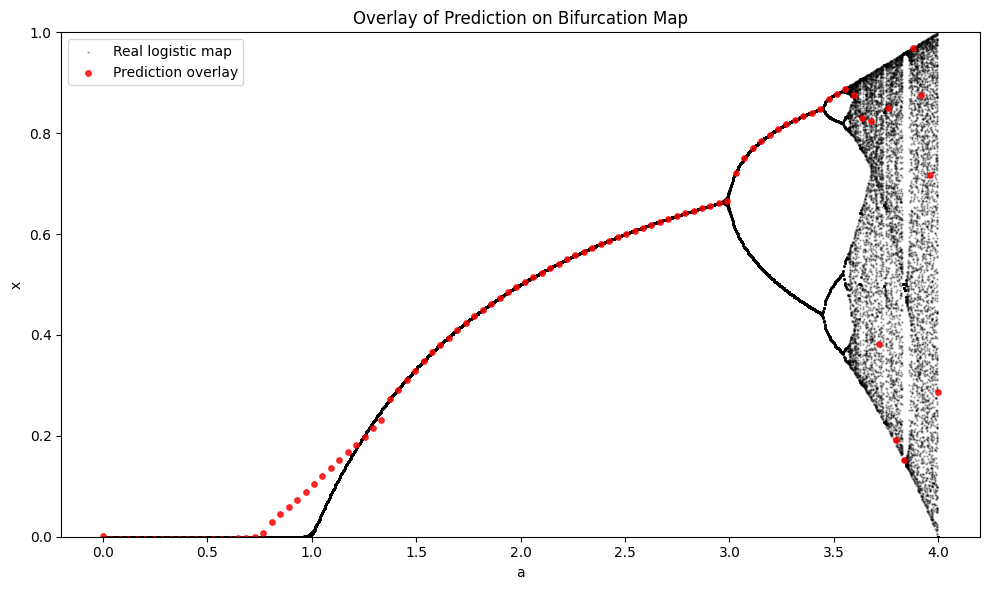

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

class PredictionModel:
    def __init__(self):
        self.model = Sequential()
        self.model.add(Dense(64, activation='relu', input_shape=(2,)))
        self.model.add(Dense(64, activation='relu'))
        self.model.add(Dense(1))
        self.model.compile(optimizer='adam', loss='mse')

    def train_model(self, X, y):
        self.model.fit(X, y, epochs=200, batch_size=128, verbose=1)

    def predict(self, start, stop, steps, discard, keep):
        a_vals = np.linspace(start, stop, steps)

        pred_points = []
        counter = 0

        for a in a_vals:
            counter += 1
            print(f"{counter}/{steps}")

            # All calculations use the same initial x value
            x = 0.5

            # Discard phase, so the system stabilises
            for _ in range(discard):
                x = self.model.predict(np.array([[a, x]]), verbose=0)[0][0]

            # Then we start saving the values
            for _ in range(keep):
                x = self.model.predict(np.array([[a, x]]), verbose=0)[0][0]
                pred_points.append((a, x))

        return pred_points

class LogisticMap:
    @staticmethod
    def function(a, x):
        return a * x * (1 - x)

    @staticmethod
    def compute_logistic_map(start, stop, steps, discard, keep):
        a_vals = np.linspace(start, stop, steps)
        values = []

        for a in a_vals:
            x = 0.5
            # Discard phase
            for _ in range(discard):
                x = LogisticMap.function(a, x)

            # Keep phase
            for _ in range(keep):
                x = LogisticMap.function(a, x)
                values.append((a, x))

        return values

    @staticmethod
    def generate_training_data(start, stop, steps, discard, keep):
        a_vals = np.linspace(start, stop, steps)
        X = []
        y = []

        for a in a_vals:
            x = 0.5

            # Discard phase
            for _ in range(discard):
                x = LogisticMap.function(a, x)

            # Keep phase
            for _ in range(keep):
                X.append([a, x])
                x_new = LogisticMap.function(a, x)
                y.append(x_new)
                x = x_new

        return np.array(X), np.array(y)


def visualize_training_and_prediction(X_train, y_train, pred_points):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Training
    a_train = X_train[:, 0]
    axes[0].scatter(a_train, y_train, color='black', s=1, alpha=0.5)
    axes[0].set_title("Training Data")
    axes[0].set_xlabel("a")
    axes[0].set_ylabel("x")
    axes[0].set_ylim(0, 1)

    # Right: Prediction
    a_pred, x_pred = zip(*pred_points)
    axes[1].scatter(a_pred, x_pred, color='red', s=5, alpha=0.5)
    axes[1].set_title("Network Prediction")
    axes[1].set_xlabel("a")
    axes[1].set_ylabel("x")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


def visualize_bifurcation_overlay(real_points, pred_single):
    a_real, x_real = zip(*real_points)
    a_pred, x_pred = zip(*pred_single)

    plt.figure(figsize=(10, 6))
    plt.scatter(a_real, x_real, color='black', s=0.5, alpha=0.3, label="Real logistic map")
    plt.scatter(a_pred, x_pred, color='red', s=15, alpha=0.8, label="Prediction overlay")

    plt.title("Overlay of Prediction on Bifurcation Map")
    plt.xlabel("a")
    plt.ylabel("x")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    start = 0.0
    stop = 4.0
    discard = 100
    keep = 100

    print("Generating training data...")
    X_train, y_train = LogisticMap.generate_training_data(
        start=start, stop=stop, steps=1000, discard=discard, keep=keep
    )

    print("Training model...")
    model = PredictionModel()
    model.train_model(X_train, y_train)

    print(f"Predicting full bifurcation (keep={keep})...")
    predicted_map = model.predict(
        start=start, stop=stop, steps=32, discard=discard, keep=keep
    )

    print("Predicting single path...")
    predicted_single = model.predict(
        start=start, stop=stop, steps=100, discard=discard, keep=1
    )

    print("Generating reference logistic map...")
    logistic_reference = LogisticMap.compute_logistic_map(
        start=start, stop=stop, steps=1000, discard=discard, keep=keep
    )

    print("Visualizing training and prediction...")
    visualize_training_and_prediction(X_train, y_train, predicted_map)

    print("Visualizing single path prediction...")
    visualize_bifurcation_overlay(logistic_reference, predicted_single)
